In [36]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from googleapiclient.discovery import build
from transformers import pipeline
from dotenv import load_dotenv
from datetime import datetime, timezone
from dateutil.relativedelta import relativedelta
from atproto import Client

In [37]:
emotion_classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base")
print("Model loaded successfully!")

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 69300.07it/s]


Model loaded successfully!


In [40]:
import os
import pandas as pd
from dotenv import load_dotenv
from atproto import Client
from datetime import datetime, timezone
from dateutil.relativedelta import relativedelta

# Load environment variables
load_dotenv()
BSKY_HANDLE = os.getenv('BSKY_HANDLE')
BSKY_PASSWORD = os.getenv('BSKY_PASSWORD')

# Keep exactly the same timeline as the YouTube analysis
SEARCH_QUERY = 'AI Bubble'
START_DATE = datetime(2024, 1, 1, tzinfo=timezone.utc)
END_DATE = datetime(2025, 12, 31, tzinfo=timezone.utc)
POSTS_PER_MONTH = 100

# Authenticate
client = Client()
client.login(BSKY_HANDLE, BSKY_PASSWORD)
print("Connected to Bluesky successfully!")

all_bsky_data = []
current_date = START_DATE

print(f"Starting temporal Bluesky analysis from {START_DATE.year} to {END_DATE.year}...")

while current_date < END_DATE:
    next_month = current_date + relativedelta(months=1)
    month_label = current_date.strftime('%Y-%m')
    print(f"Processing Bluesky posts for {month_label}...")
    
    # Construct a time-constrained search query
    # Bluesky expects ISO 8601 format for dates in queries
    date_query = f'{SEARCH_QUERY} since:{current_date.strftime("%Y-%m-%dT%H:%M:%SZ")} until:{next_month.strftime("%Y-%m-%dT%H:%M:%SZ")}'
    
    try:
        # Fetch the top posts for this specific month
        response = client.app.bsky.feed.search_posts({
            'q': date_query, 
            'limit': POSTS_PER_MONTH,
            'sort': 'top' 
        })
        
        for post in response.posts:
            text = post.record.text
            
            # Extract engagement safely
            likes = getattr(post, 'like_count', 0)
            reposts = getattr(post, 'repost_count', 0)
            influence_weight = 1 + likes + reposts
            
            # Analyze emotion
            safe_text = text[:500] 
            result = emotion_classifier(safe_text)[0]
            
            all_bsky_data.append({
                "Month": month_label,
                "Date": pd.to_datetime(post.record.created_at),
                "Emotion": result['label'],
                "Weight": influence_weight
            })
            
    except Exception as e:
        print(f"  -> Error fetching data for {month_label}: {e}")
        
    current_date = next_month

bsky_df = pd.DataFrame(all_bsky_data)
bsky_df['Month'] = pd.to_datetime(bsky_df['Month'])

print(f"\nDone! Analyzed a total of {len(bsky_df)} timestamped posts.")
display(bsky_df.head())

Connected to Bluesky successfully!
Starting temporal Bluesky analysis from 2024 to 2025...
Processing Bluesky posts for 2024-01...
Processing Bluesky posts for 2024-02...
Processing Bluesky posts for 2024-03...
Processing Bluesky posts for 2024-04...
Processing Bluesky posts for 2024-05...
Processing Bluesky posts for 2024-06...
Processing Bluesky posts for 2024-07...
Processing Bluesky posts for 2024-08...
Processing Bluesky posts for 2024-09...
Processing Bluesky posts for 2024-10...
Processing Bluesky posts for 2024-11...
Processing Bluesky posts for 2024-12...
Processing Bluesky posts for 2025-01...
Processing Bluesky posts for 2025-02...
Processing Bluesky posts for 2025-03...
Processing Bluesky posts for 2025-04...
Processing Bluesky posts for 2025-05...
Processing Bluesky posts for 2025-06...
Processing Bluesky posts for 2025-07...
Processing Bluesky posts for 2025-08...
Processing Bluesky posts for 2025-09...
Processing Bluesky posts for 2025-10...
Processing Bluesky posts for 

,Month,Date,Emotion,Weight
0,2024-01-01,2024-01-02 11:56:23.598000+00:00,neutral,1
1,2024-01-01,2024-01-25 23:04:27.281000+00:00,neutral,1
2,2024-01-01,2024-01-06 18:24:20.584000+00:00,neutral,2
3,2024-01-01,2024-01-26 14:52:17.730000+00:00,neutral,7
4,2024-01-01,2024-01-10 01:11:10.826000+00:00,neutral,2


In [41]:
# --- Scenario A: Standard Unweighted Sentiment ---
standard_counts = bsky_df['Emotion'].value_counts()
standard_pct = (standard_counts / standard_counts.sum()) * 100

# --- Scenario B: Engagement-Weighted Sentiment ---
weighted_counts = bsky_df.groupby('Emotion')['Weight'].sum()
weighted_pct = (weighted_counts / weighted_counts.sum()) * 100

# Combine into a comparison DataFrame
comparison_df = pd.DataFrame({
    'Standard (%)': standard_pct,
    'Weighted (%)': weighted_pct
}).fillna(0)

# Sort by standard sentiment so the graph looks organized
comparison_df = comparison_df.sort_values(by='Standard (%)', ascending=False)

print("Mathematical Comparison Complete:")
display(comparison_df.round(2))

Mathematical Comparison Complete:


,Standard (%),Weighted (%)
Emotion,,
neutral,46.73,49.45
fear,15.00,9.87
surprise,10.66,8.66
anger,10.31,12.25
disgust,7.83,10.20
joy,5.49,4.60
sadness,3.98,4.95


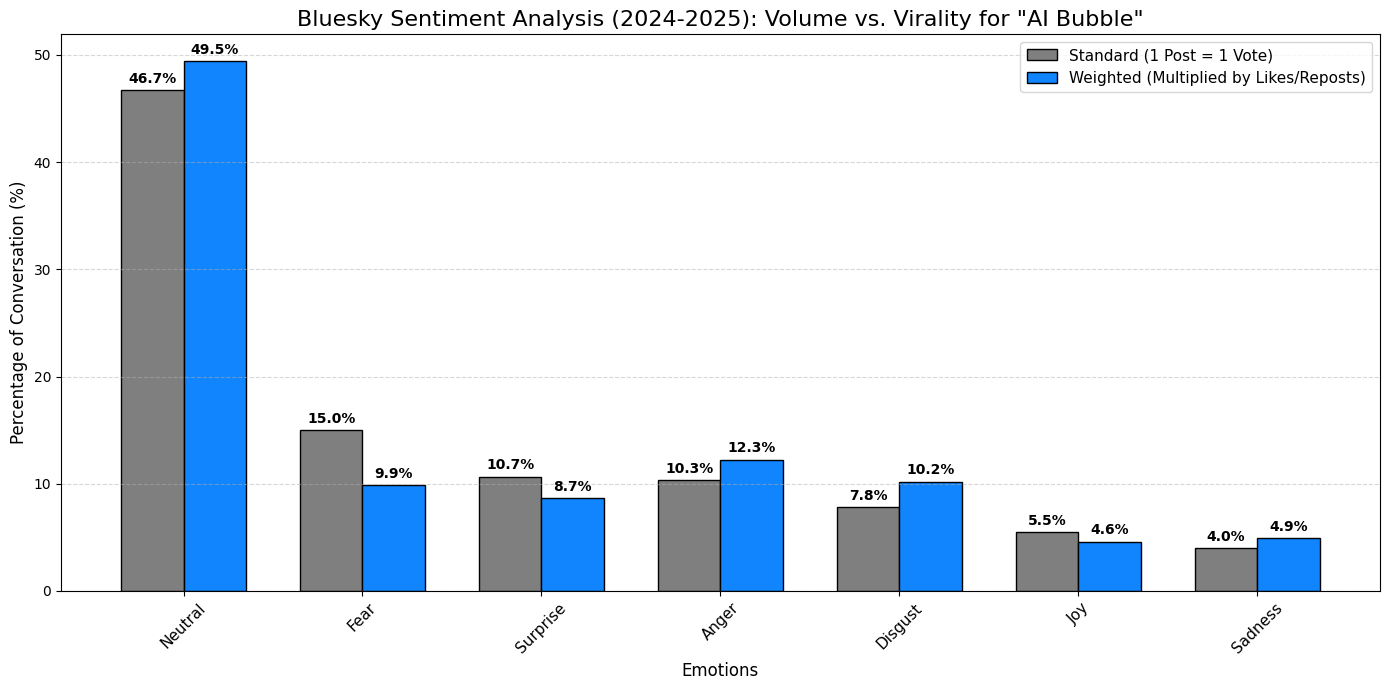

In [42]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(comparison_df.index))
width = 0.35  

# Plot both scenarios side-by-side
rects1 = ax.bar(x - width/2, comparison_df['Standard (%)'], width, label='Standard (1 Post = 1 Vote)', color='#7f7f7f', edgecolor='black')
rects2 = ax.bar(x + width/2, comparison_df['Weighted (%)'], width, label='Weighted (Multiplied by Likes/Reposts)', color='#1185fe', edgecolor='black') # Bluesky Blue

# Formatting
ax.set_title(f'Bluesky Sentiment Analysis (2024-2025): Volume vs. Virality for "{SEARCH_QUERY}"', fontsize=16)
ax.set_ylabel('Percentage of Conversation (%)', fontsize=12)
ax.set_xlabel('Emotions', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index.str.capitalize(), rotation=45, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add exact percentage numbers on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

In [43]:
print("Fetching NVDA stock data...")
nvda_data = yf.download(
    "NVDA", 
    start=START_DATE.strftime('%Y-%m-%d'), 
    end=END_DATE.strftime('%Y-%m-%d'),
    interval="1mo" 
)

# Flatten the MultiIndex to prevent MergeErrors
if isinstance(nvda_data.columns, pd.MultiIndex):
    nvda_close = nvda_data['Close'].copy()
    nvda_close.columns = ['NVDA_Price']
else:
    nvda_close = nvda_data[['Close']].rename(columns={'Close': 'NVDA_Price'})

nvda_close.index = nvda_close.index.tz_localize(None)
print("NVDA data fetched and formatted successfully!")

[*********************100%***********************]  1 of 1 completed

Fetching NVDA stock data...
NVDA data fetched and formatted successfully!


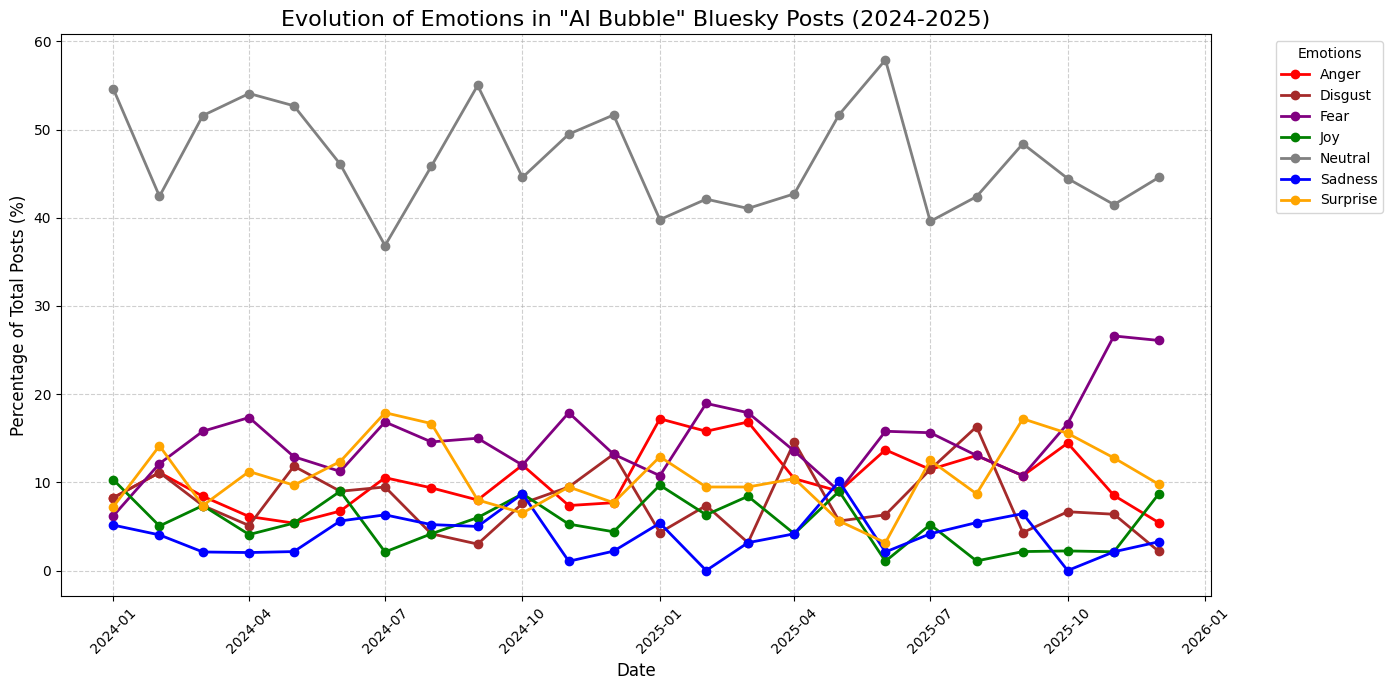

In [44]:
# Group data by Month and Emotion (Standard 1 Post = 1 Vote)
bsky_temporal = bsky_df.groupby(['Month', 'Emotion']).size().unstack(fill_value=0)
bsky_temporal_pct = bsky_temporal.div(bsky_temporal.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 7))

colors = {
    'anger': 'red', 'disgust': 'brown', 'fear': 'purple', 
    'joy': 'green', 'neutral': 'gray', 'sadness': 'blue', 'surprise': 'orange'
}

for emotion in bsky_temporal_pct.columns:
    plt.plot(
        bsky_temporal_pct.index, 
        bsky_temporal_pct[emotion], 
        marker='o', 
        linewidth=2, 
        label=emotion.capitalize(),
        color=colors.get(emotion, 'black')
    )

plt.title(f'Evolution of Emotions in "{SEARCH_QUERY}" Bluesky Posts (2024-2025)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Percentage of Total Posts (%)', fontsize=12)
plt.legend(title='Emotions', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

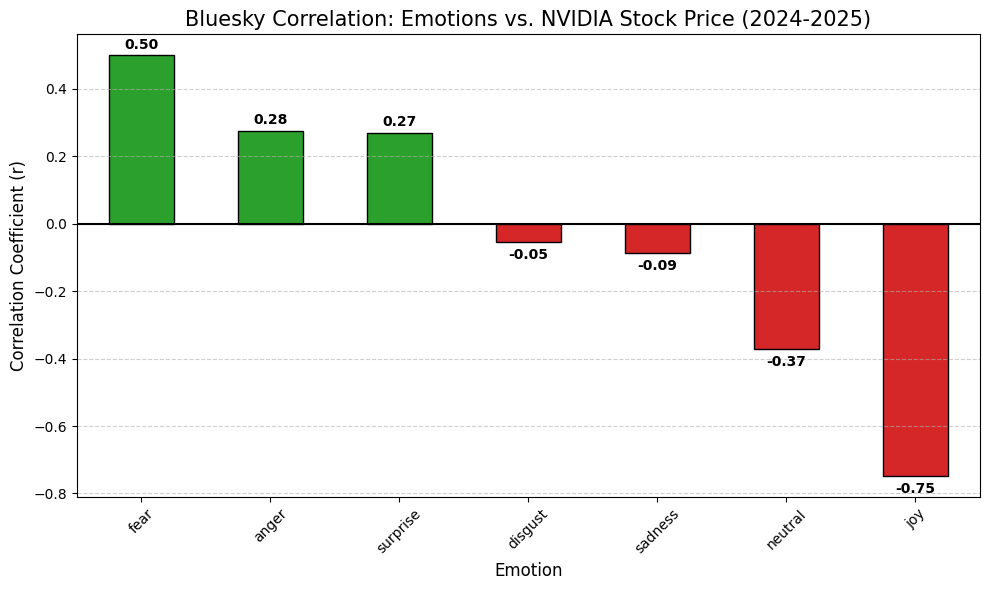

In [46]:
# Strip timezones and merge
bsky_temporal_pct.index = bsky_temporal_pct.index.tz_localize(None)
bsky_merged_df = bsky_temporal_pct.join(nvda_close, how='inner')

# Smooth the data and calculate correlation
rolling_months = 2
bsky_smoothed = bsky_merged_df.rolling(window=rolling_months, min_periods=1).mean()
bsky_correlation_matrix = bsky_smoothed.corr()
bsky_nvda_correlations = bsky_correlation_matrix['NVDA_Price'].drop('NVDA_Price').sort_values(ascending=False)

plt.figure(figsize=(10, 6))

bar_colors = ['#2ca02c' if val > 0 else '#d62728' for val in bsky_nvda_correlations.values]
ax = bsky_nvda_correlations.plot(kind='bar', color=bar_colors, edgecolor='black')
plt.axhline(0, color='black', linewidth=1.5)

plt.title('Bluesky Correlation: Emotions vs. NVIDIA Stock Price (2024-2025)', fontsize=15)
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Correlation Coefficient (r)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for i, v in enumerate(bsky_nvda_correlations.values):
    y_pos = v + 0.02 if v > 0 else v - 0.05
    plt.text(i, y_pos, f"{v:.2f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

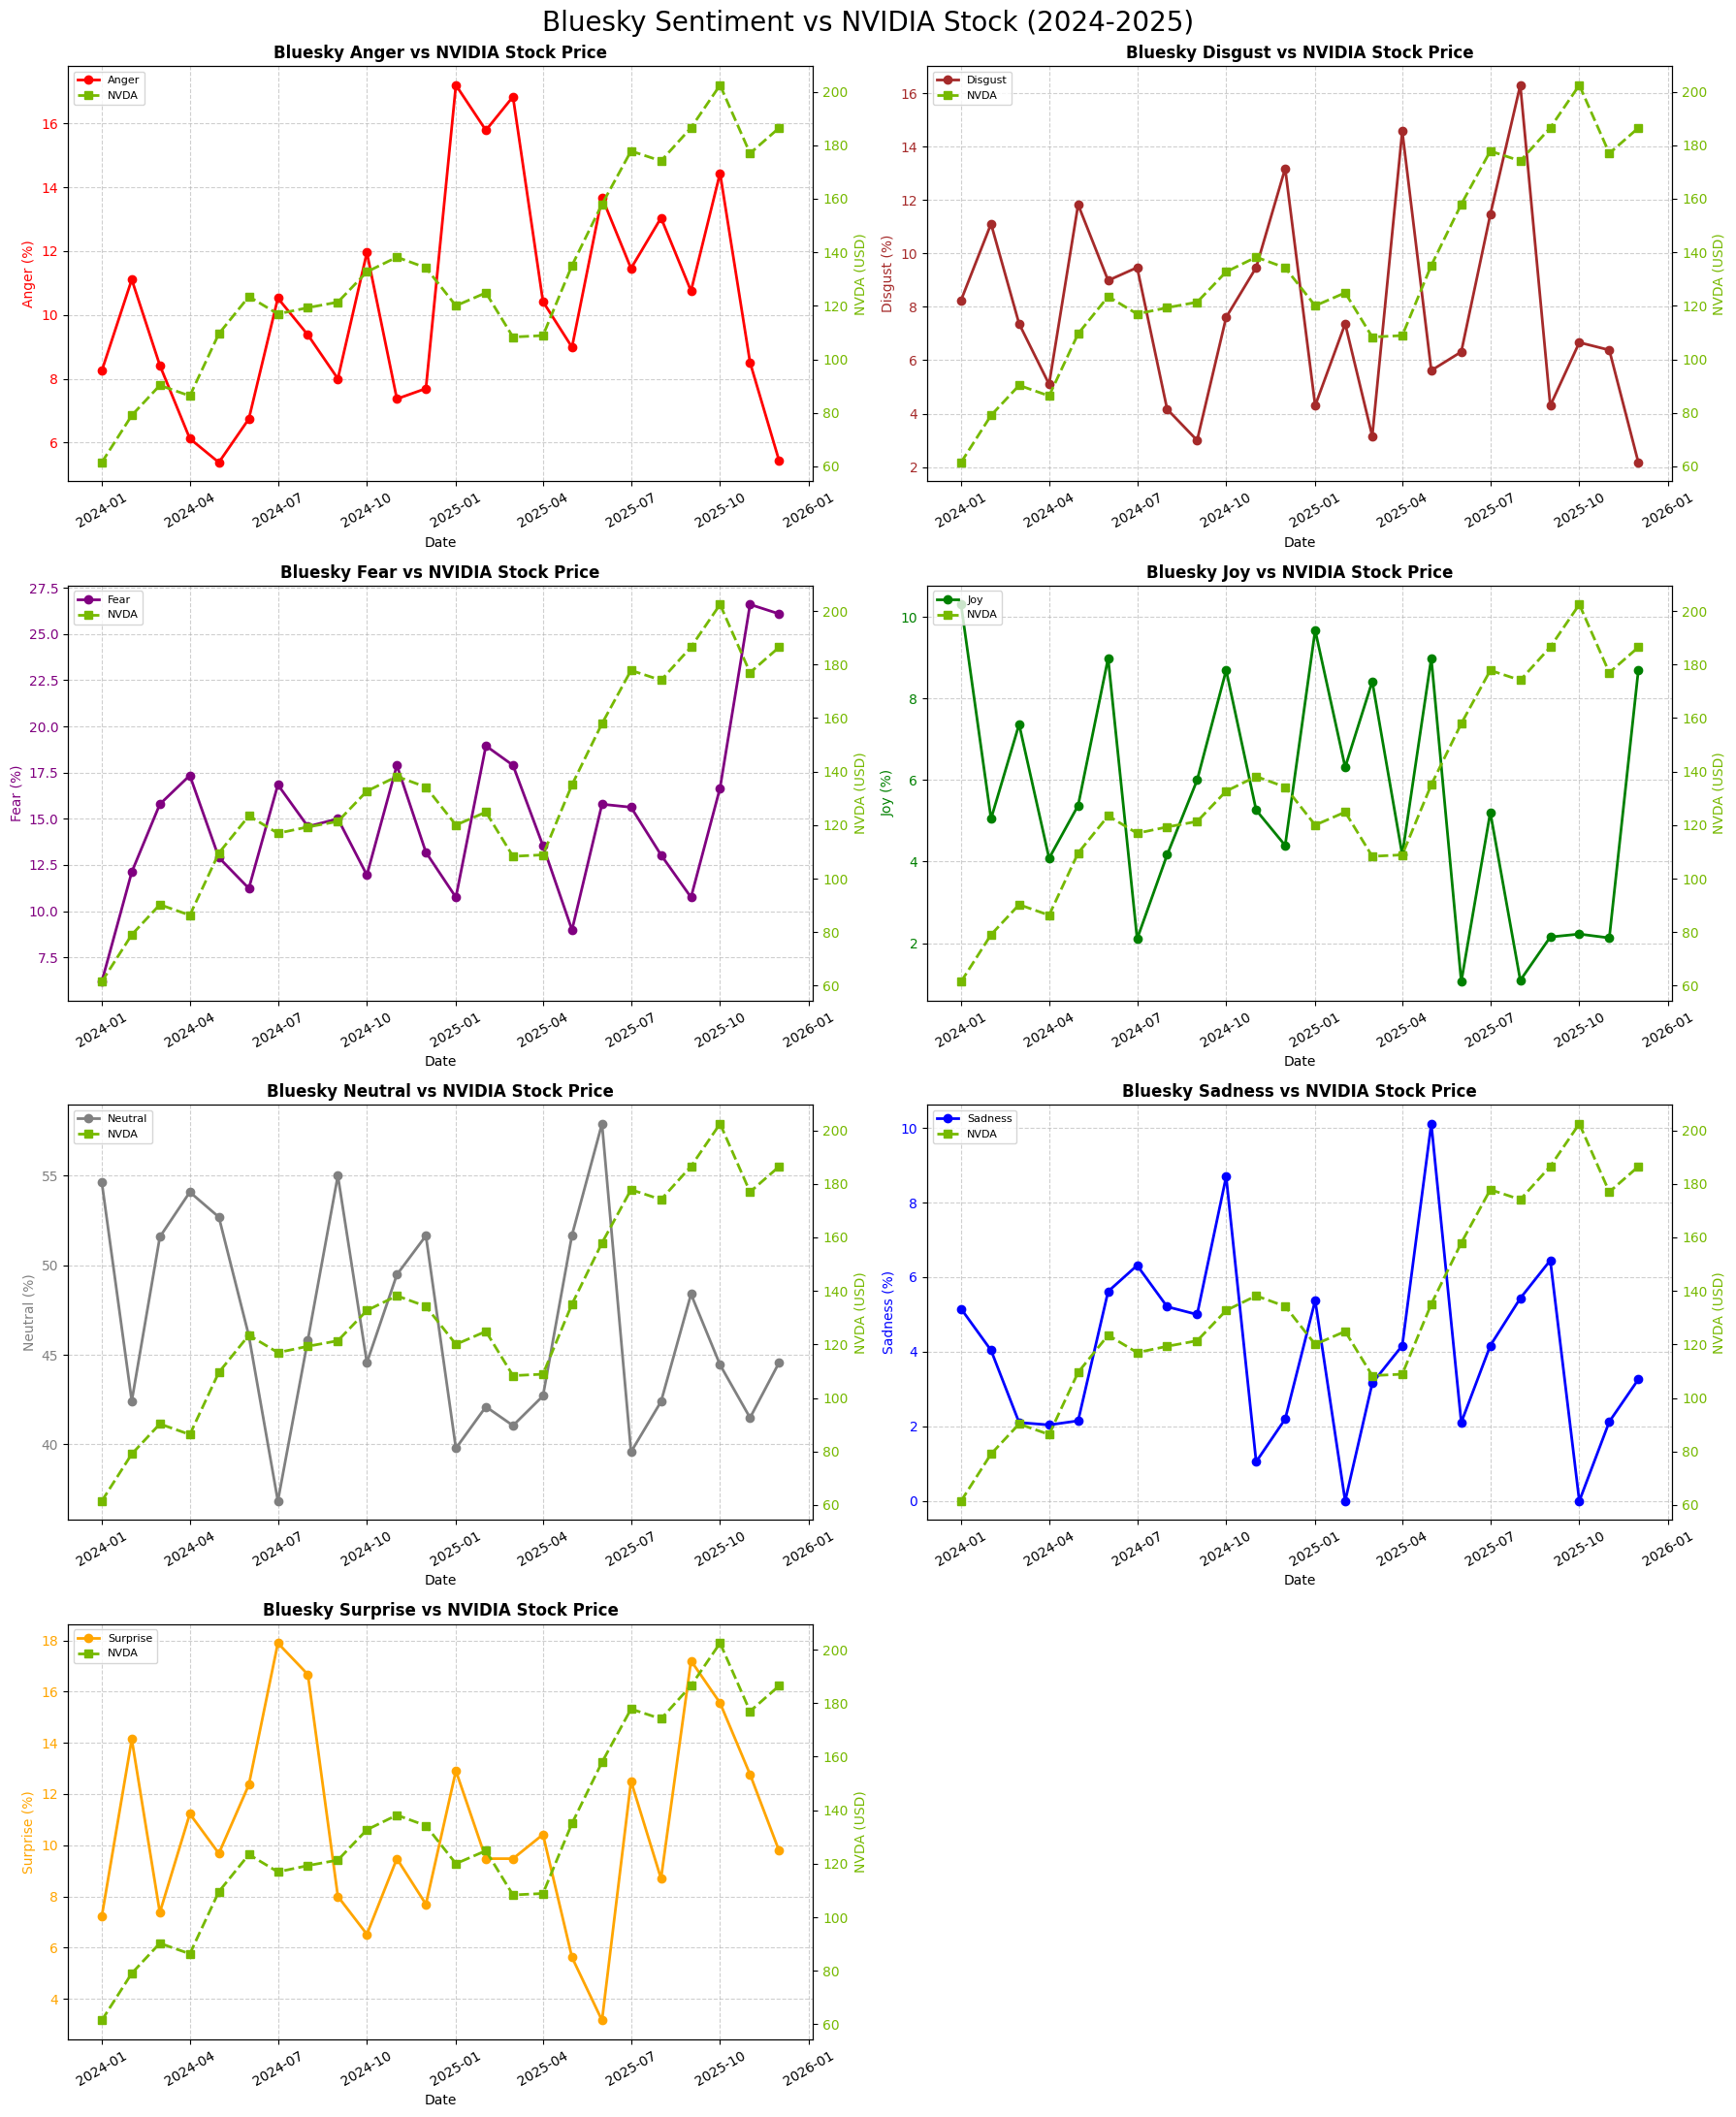

In [47]:
emotions_list = [col for col in bsky_merged_df.columns if col != 'NVDA_Price']
color_stock = '#76b900'

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 22))
axes = axes.flatten()

for i, emotion in enumerate(emotions_list):
    ax1 = axes[i]
    color_emotion = colors.get(emotion, 'black')
    
    # Emotion line
    ax1.set_xlabel('Date', fontsize=10)
    ax1.set_ylabel(f'{emotion.capitalize()} (%)', color=color_emotion, fontsize=10)
    ax1.plot(bsky_merged_df.index, bsky_merged_df[emotion], color=color_emotion, marker='o', linewidth=2, label=f'{emotion.capitalize()}')
    ax1.tick_params(axis='y', labelcolor=color_emotion)
    ax1.grid(True, linestyle='--', alpha=0.6)

    # NVDA Stock line
    ax2 = ax1.twinx()  
    ax2.set_ylabel('NVDA (USD)', color=color_stock, fontsize=10)
    ax2.plot(bsky_merged_df.index, bsky_merged_df['NVDA_Price'], color=color_stock, marker='s', linewidth=2, linestyle='--', label='NVDA')
    ax2.tick_params(axis='y', labelcolor=color_stock)

    # Unified Legend
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=8)

    ax1.set_title(f'Bluesky {emotion.capitalize()} vs NVIDIA Stock Price', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='x', rotation=30)

# Hide the last empty plot
axes[7].set_visible(False)

fig.suptitle('Bluesky Sentiment vs NVIDIA Stock (2024-2025)', fontsize=20, y=0.99)
fig.tight_layout()
plt.show()

Fetching true global post volume for 'AI Bubble' across Bluesky...


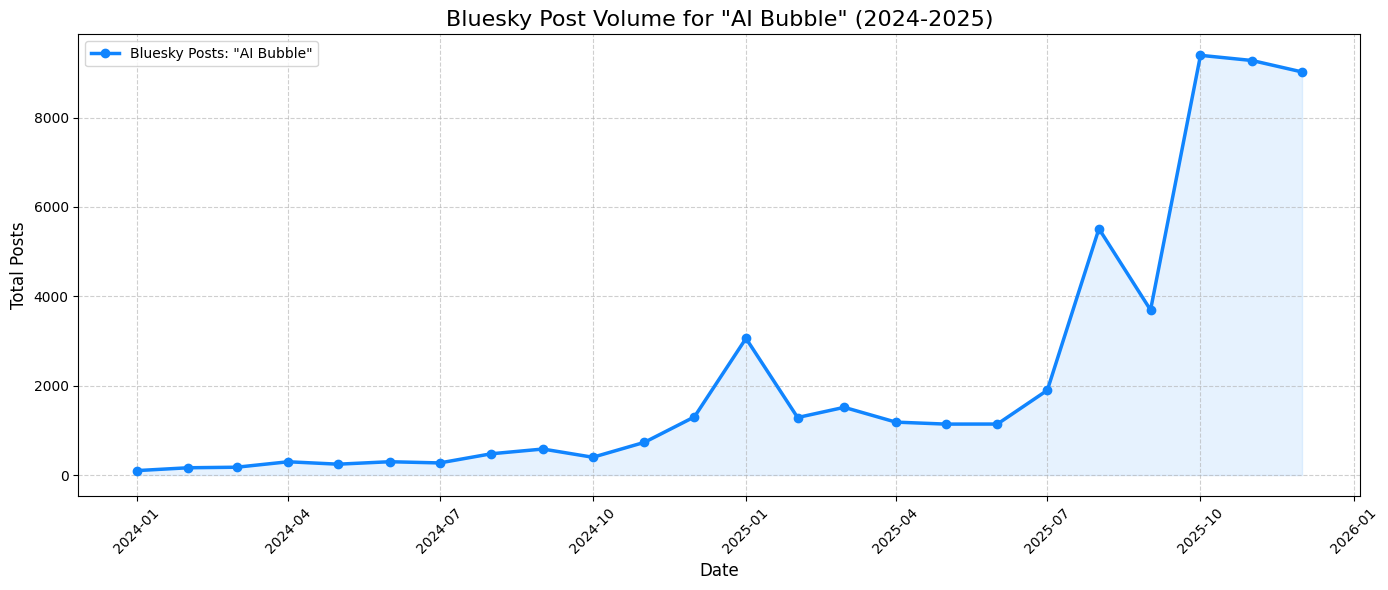

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta

# --- 1. Fetch True Global Post Volume via Pagination ---
bsky_global_counts = []
current_date = START_DATE

print(f"Fetching true global post volume for '{SEARCH_QUERY}' across Bluesky...")

while current_date < END_DATE:
    next_month = current_date + relativedelta(months=1)
    month_label = current_date.strftime('%Y-%m')
    
    date_query = f'{SEARCH_QUERY} since:{current_date.strftime("%Y-%m-%dT%H:%M:%SZ")} until:{next_month.strftime("%Y-%m-%dT%H:%M:%SZ")}'
    
    try:
        total_results = 0
        cursor = None
        
        # Paginate through the month to count exactly how many posts exist
        while True:
            response = client.app.bsky.feed.search_posts({
                'q': date_query, 
                'limit': 100, 
                'cursor': cursor
            })
            
            total_results += len(response.posts)
            cursor = getattr(response, 'cursor', None)
            
            if not cursor:
                break
                
        bsky_global_counts.append({
            "Month": month_label,
            "Total_Posts": total_results
        })
        
    except Exception as e:
        print(f"Error fetching data for {month_label}: {e}")
        
    current_date = next_month

bsky_volume_df = pd.DataFrame(bsky_global_counts)
bsky_volume_df['Month'] = pd.to_datetime(bsky_volume_df['Month'])

# --- 2. Plot the Content Creation Trend ---
plt.figure(figsize=(14, 6))

# Plot the total posts as a distinct Bluesky blue line
plt.plot(
    bsky_volume_df['Month'], 
    bsky_volume_df['Total_Posts'], 
    color='#1185fe', 
    marker='o',
    linewidth=2.5,
    label=f'Bluesky Posts: "{SEARCH_QUERY}"'
)

# Fill the area under the line to match your YouTube graph style
plt.fill_between(
    bsky_volume_df['Month'], 
    bsky_volume_df['Total_Posts'], 
    color='#1185fe', 
    alpha=0.10
)

# Formatting and Labels
plt.title(f'Bluesky Post Volume for "{SEARCH_QUERY}" (2024-2025)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Posts', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the graph
plt.show()